# 🔍 Credit Card Fraud Detection — Notebook 2: Classification Analysis
**Statistics & Probability — Final Research Project**
Team Nekat Part 100 · Felicia Sword · 0706012410012 · May 2026

---
**Research question.** Among **K-Nearest Neighbor (KNN)** and **Logistic Regression (LR)**, which best classifies credit-card fraud on this highly imbalanced dataset, and how does **SMOTE** affect their relative performance?

This notebook *continues from* **Notebook 1 (EDA & Data Preparation — Stages 1–6)**: it loads the cleaned, feature-engineered dataset Notebook 1 saved, then trains and compares the models. Primary metrics: **F1 and recall** on the fraud (minority) class.


## Setup · Imports & Prepared Data
Re-imports the libraries and loads the cleaned dataset saved by Notebook 1
(run `01_eda.ipynb` first if `data/data_clean.csv` is missing).


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from math import radians, cos, sin, asin, sqrt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, accuracy_score,
                             precision_score, recall_score, f1_score,
                             average_precision_score, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('../outputs', exist_ok=True)

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print('All libraries loaded successfully.')


All libraries loaded successfully.


In [2]:
df = pd.read_csv('../data/data_clean.csv')
print(f'Loaded {len(df):,} rows, {df.shape[1]} columns | fraud rate {df["is_fraud"].mean()*100:.2f}%')
df[['amt', 'amt_zscore_card', 'hours_since_prev', 'txns_24h', 'is_fraud']].head()


Loaded 100,000 rows, 31 columns | fraud rate 0.52%


,amt,amt_zscore_card,hours_since_prev,txns_24h,is_fraud
0,67.72,0.096734,2.202222,5.0,0
1,206.98,0.848728,0.295833,17.0,0
2,68.79,-0.132438,14.346944,2.0,0
3,69.82,0.030642,14.871667,2.0,0
4,31.53,-0.436970,4.022500,5.0,0


---
## Stage 7 · Classification Data Preparation
### 7.1 Feature Matrix Construction


In [3]:
# One-hot encode category (X1) — drop_first to avoid multicollinearity
cat_dummies = pd.get_dummies(df['category'], prefix='cat', drop_first=True).astype(int)

# One-hot encode day_of_week (X6)
dow_dummies = pd.get_dummies(df['day_of_week'], prefix='dow', drop_first=True).astype(int)

# Numerical features: gender_enc (X2), age (X3), city_pop (X4), hour (X5), is_weekend (X7),
# distance (X8), amt_zscore_card (replaces raw amt — encodes amount in context of each card's
# own history, strictly more informative and avoids multicollinearity with amt, r=0.738),
# hours_since_prev, txns_24h
num_features = df[['gender_enc', 'age', 'city_pop', 'hour', 'is_weekend', 'distance',
                   'amt_zscore_card', 'hours_since_prev', 'txns_24h']]

# Combine all features
X = pd.concat([cat_dummies, dow_dummies, num_features], axis=1).astype(float)
y = df['is_fraud']

print(f'Feature matrix shape: {X.shape}')
print(f'Features ({X.shape[1]} total):')
print(f'  - Category dummies: {cat_dummies.shape[1]}')
print(f'  - Day-of-week dummies: {dow_dummies.shape[1]}')
print(f'  - Numerical: gender_enc, age, city_pop, hour, is_weekend, distance')
print(f'  - Behavioral: amt_zscore_card (replaces raw amt), hours_since_prev, txns_24h')
print(f'  Note: raw amt dropped — amt_zscore_card is strictly more informative and avoids')
print(f'        multicollinearity (amt x amt_zscore_card r=0.738)')
print(f'\nClass distribution:\n{y.value_counts().to_string()}')


Feature matrix shape: (100000, 28)
Features (28 total):
  - Category dummies: 13
  - Day-of-week dummies: 6
  - Numerical: gender_enc, age, city_pop, hour, is_weekend, distance
  - Behavioral: amt_zscore_card (replaces raw amt), hours_since_prev, txns_24h
  Note: raw amt dropped — amt_zscore_card is strictly more informative and avoids
        multicollinearity (amt x amt_zscore_card r=0.738)

Class distribution:
is_fraud
0    99479
1      521


### 7.2 Stratified Train-Test Split (80:20)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Train fraud rate: {y_train.mean()*100:.2f}%')
print(f'Test  fraud rate: {y_test.mean()*100:.2f}%')


Train: 80,000 | Test: 20,000
Train fraud rate: 0.52%
Test  fraud rate: 0.52%


### 7.3 Standardization (Z-score)


In [5]:
# Standardization is critical for KNN (distance-based) and beneficial for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(f'Scaled train shape: {X_train_scaled.shape}')
print(f'Scaled test shape:  {X_test_scaled.shape}')


Scaled train shape: (80000, 28)
Scaled test shape:  (20000, 28)


### 7.4 SMOTE Oversampling (Training Data Only)


In [6]:
smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f'Before SMOTE: {len(X_train_scaled):,} samples')
print(f'After  SMOTE: {len(X_train_smote):,} samples')
print(f'\nClass distribution after SMOTE:')
print(pd.Series(y_train_smote).value_counts().to_string())
print(f'\n⚠️ SMOTE applied ONLY to training data. Test set remains unmodified.')


Before SMOTE: 80,000 samples
After  SMOTE: 159,166 samples

Class distribution after SMOTE:
is_fraud
0    79583
1    79583

⚠️ SMOTE applied ONLY to training data. Test set remains unmodified.


---
## Stage 8 · KNN Classification — Baseline (No SMOTE)
### 8.1 Optimal k Selection via 5-Fold Stratified CV


In [7]:
k_candidates = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]  # odd numbers only (avoids ties), consistent step of 2
cv_results_knn = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for k in k_candidates:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=skf, scoring='f1')
    cv_results_knn.append({'k': k, 'mean_f1': scores.mean(), 'std_f1': scores.std()})
    print(f'k={k:2d} → F1={scores.mean():.4f} ± {scores.std():.4f}')

best_k_base = max(cv_results_knn, key=lambda x: x['mean_f1'])['k']
print(f'\n✅ Best k (baseline): {best_k_base}')


k= 1 → F1=0.3351 ± 0.0616


k= 3 → F1=0.2731 ± 0.0413


k= 5 → F1=0.2282 ± 0.0331


k= 7 → F1=0.2175 ± 0.0340


k= 9 → F1=0.2068 ± 0.0511


...

k=13 → F1=0.1778 ± 0.0299


k=15 → F1=0.1508 ± 0.0491


k=17 → F1=0.1312 ± 0.0308


k=19 → F1=0.1065 ± 0.0327


k=21 → F1=0.0898 ± 0.0147

✅ Best k (baseline): 1


### 8.2 KNN Baseline — Train & Evaluate


In [8]:
knn_base = KNeighborsClassifier(n_neighbors=best_k_base)
knn_base.fit(X_train_scaled, y_train)
y_pred_knn_base = knn_base.predict(X_test_scaled)
y_prob_knn_base = knn_base.predict_proba(X_test_scaled)[:, 1]

print('=== KNN Baseline (No SMOTE) ===')
print(f'k = {best_k_base}\n')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_knn_base))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_knn_base, target_names=['Legitimate','Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_knn_base):.4f}')


=== KNN Baseline (No SMOTE) ===
k = 1

Confusion Matrix:
[[19867    29]
 [   70    34]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     19896
       Fraud       0.54      0.33      0.41       104

    accuracy                           1.00     20000
   macro avg       0.77      0.66      0.70     20000
weighted avg       0.99      1.00      0.99     20000

ROC-AUC: 0.6627


---
## Stage 9 · KNN Classification — With SMOTE
### 9.1 Optimal k Selection via 5-Fold Stratified CV (SMOTE inside CV)


In [9]:
# Use imblearn Pipeline to apply SMOTE inside each CV fold (prevents data leakage)
cv_results_knn_smote = []
for k in k_candidates:
    pipe = ImbPipeline([('smote', SMOTE(random_state=SEED)),
                        ('knn', KNeighborsClassifier(n_neighbors=k))])
    scores = cross_val_score(pipe, X_train_scaled, y_train, cv=skf, scoring='f1')
    cv_results_knn_smote.append({'k': k, 'mean_f1': scores.mean(), 'std_f1': scores.std()})
    print(f'k={k:2d} → F1={scores.mean():.4f} ± {scores.std():.4f}')

best_k_smote = max(cv_results_knn_smote, key=lambda x: x['mean_f1'])['k']
print(f'\n✅ Best k (SMOTE): {best_k_smote}')


k= 1 → F1=0.3100 ± 0.0370


k= 3 → F1=0.2649 ± 0.0198


k= 5 → F1=0.2344 ± 0.0181


k= 7 → F1=0.2152 ± 0.0163


k= 9 → F1=0.1975 ± 0.0147


...

k=13 → F1=0.1687 ± 0.0138


k=15 → F1=0.1594 ± 0.0128


k=17 → F1=0.1531 ± 0.0104


k=19 → F1=0.1464 ± 0.0110


k=21 → F1=0.1393 ± 0.0101

✅ Best k (SMOTE): 1


### 9.2 KNN + SMOTE — Train & Evaluate


In [10]:
knn_smote = KNeighborsClassifier(n_neighbors=best_k_smote)
knn_smote.fit(X_train_smote, y_train_smote)
y_pred_knn_smote = knn_smote.predict(X_test_scaled)
y_prob_knn_smote = knn_smote.predict_proba(X_test_scaled)[:, 1]

print('=== KNN + SMOTE ===')
print(f'k = {best_k_smote}\n')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_knn_smote))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_knn_smote, target_names=['Legitimate','Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_knn_smote):.4f}')


=== KNN + SMOTE ===
k = 1

Confusion Matrix:
[[19815    81]
 [   58    46]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     19896
       Fraud       0.36      0.44      0.40       104

    accuracy                           0.99     20000
   macro avg       0.68      0.72      0.70     20000
weighted avg       0.99      0.99      0.99     20000

ROC-AUC: 0.7191


---
## Stage 10 · Logistic Regression — Baseline (No SMOTE)


In [11]:
lr_base = LogisticRegression(max_iter=1000, random_state=SEED)
lr_base.fit(X_train_scaled, y_train)
y_pred_lr_base = lr_base.predict(X_test_scaled)
y_prob_lr_base = lr_base.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression Baseline (No SMOTE) ===\n')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_lr_base))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr_base, target_names=['Legitimate','Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr_base):.4f}')


=== Logistic Regression Baseline (No SMOTE) ===

Confusion Matrix:
[[19890     6]
 [  103     1]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      1.00     19896
       Fraud       0.14      0.01      0.02       104

    accuracy                           0.99     20000
   macro avg       0.57      0.50      0.51     20000
weighted avg       0.99      0.99      0.99     20000

ROC-AUC: 0.8050


---
## Stage 11 · Logistic Regression — With SMOTE


In [12]:
lr_smote = LogisticRegression(max_iter=1000, random_state=SEED)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_lr_smote = lr_smote.predict(X_test_scaled)
y_prob_lr_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression + SMOTE ===\n')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_lr_smote))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr_smote, target_names=['Legitimate','Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr_smote):.4f}')


=== Logistic Regression + SMOTE ===

Confusion Matrix:
[[17044  2852]
 [   30    74]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.86      0.92     19896
       Fraud       0.03      0.71      0.05       104

    accuracy                           0.86     20000
   macro avg       0.51      0.78      0.49     20000
weighted avg       0.99      0.86      0.92     20000

ROC-AUC: 0.8607


---
## Stage 12 · Comparative Analysis
### 12.1 Performance Comparison Table


In [13]:
# Collect metrics for all 4 models
models = {
    'KNN Baseline':   (y_pred_knn_base,  y_prob_knn_base),
    'KNN + SMOTE':    (y_pred_knn_smote, y_prob_knn_smote),
    'LR Baseline':    (y_pred_lr_base,   y_prob_lr_base),
    'LR + SMOTE':     (y_pred_lr_smote,  y_prob_lr_smote),
}

results = []
for name, (y_pred, y_prob) in models.items():
    results.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision (Fraud)': precision_score(y_test, y_pred),
        'Recall (Fraud)':    recall_score(y_test, y_pred),
        'F1 (Fraud)':        f1_score(y_test, y_pred),
        'ROC-AUC':           roc_auc_score(y_test, y_prob),
        'PR-AUC':            average_precision_score(y_test, y_prob),
    })

df_results = pd.DataFrame(results).set_index('Model')
print('═' * 80)
print('COMPARATIVE PERFORMANCE — ALL 4 MODELS')
print('═' * 80)
print(df_results.round(4).to_string())
print()
print(f'🏆 Best F1 (Fraud):  {df_results["F1 (Fraud)"].idxmax()} ({df_results["F1 (Fraud)"].max():.4f})')
print(f'🏆 Best Recall (Fraud): {df_results["Recall (Fraud)"].idxmax()} ({df_results["Recall (Fraud)"].max():.4f})')
print(f'🏆 Best ROC-AUC:     {df_results["ROC-AUC"].idxmax()} ({df_results["ROC-AUC"].max():.4f})')


════════════════════════════════════════════════════════════════════════════════
COMPARATIVE PERFORMANCE — ALL 4 MODELS
════════════════════════════════════════════════════════════════════════════════
              Accuracy  Precision (Fraud)  Recall (Fraud)  F1 (Fraud)  ROC-AUC  PR-AUC
Model                                                                                 
KNN Baseline    0.9950             0.5397          0.3269      0.4072   0.6627  0.1799
KNN + SMOTE     0.9930             0.3622          0.4423      0.3983   0.7191  0.1631
LR Baseline     0.9946             0.1429          0.0096      0.0180   0.8050  0.2457
LR + SMOTE      0.8559             0.0253          0.7115      0.0488   0.8607  0.1918

🏆 Best F1 (Fraud):  KNN Baseline (0.4072)
🏆 Best Recall (Fraud): LR + SMOTE (0.7115)
🏆 Best ROC-AUC:     LR + SMOTE (0.8607)


### 12.2 ROC Curves — All Models


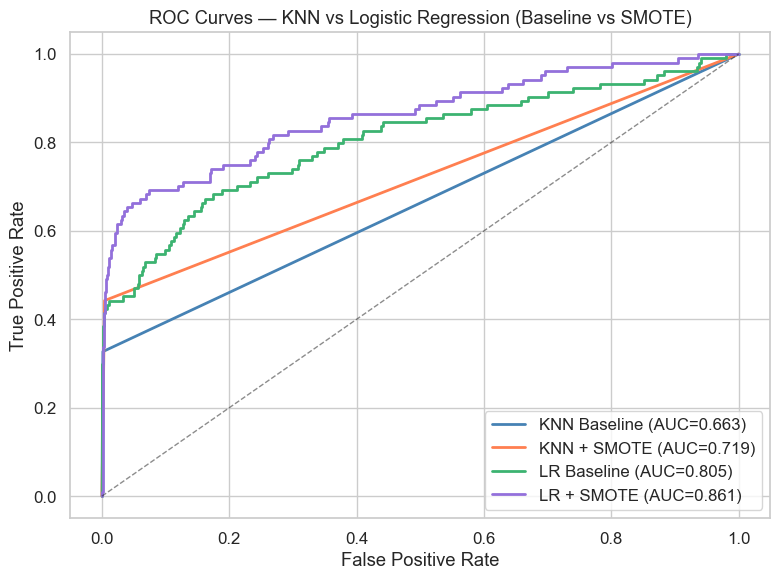

In [14]:
plt.figure(figsize=(8, 6))
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
for (name, (_, y_prob)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — KNN vs Logistic Regression (Baseline vs SMOTE)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/roc_curves_comparison.png', dpi=150)
plt.show()


### 12.3 Confusion Matrix Grid


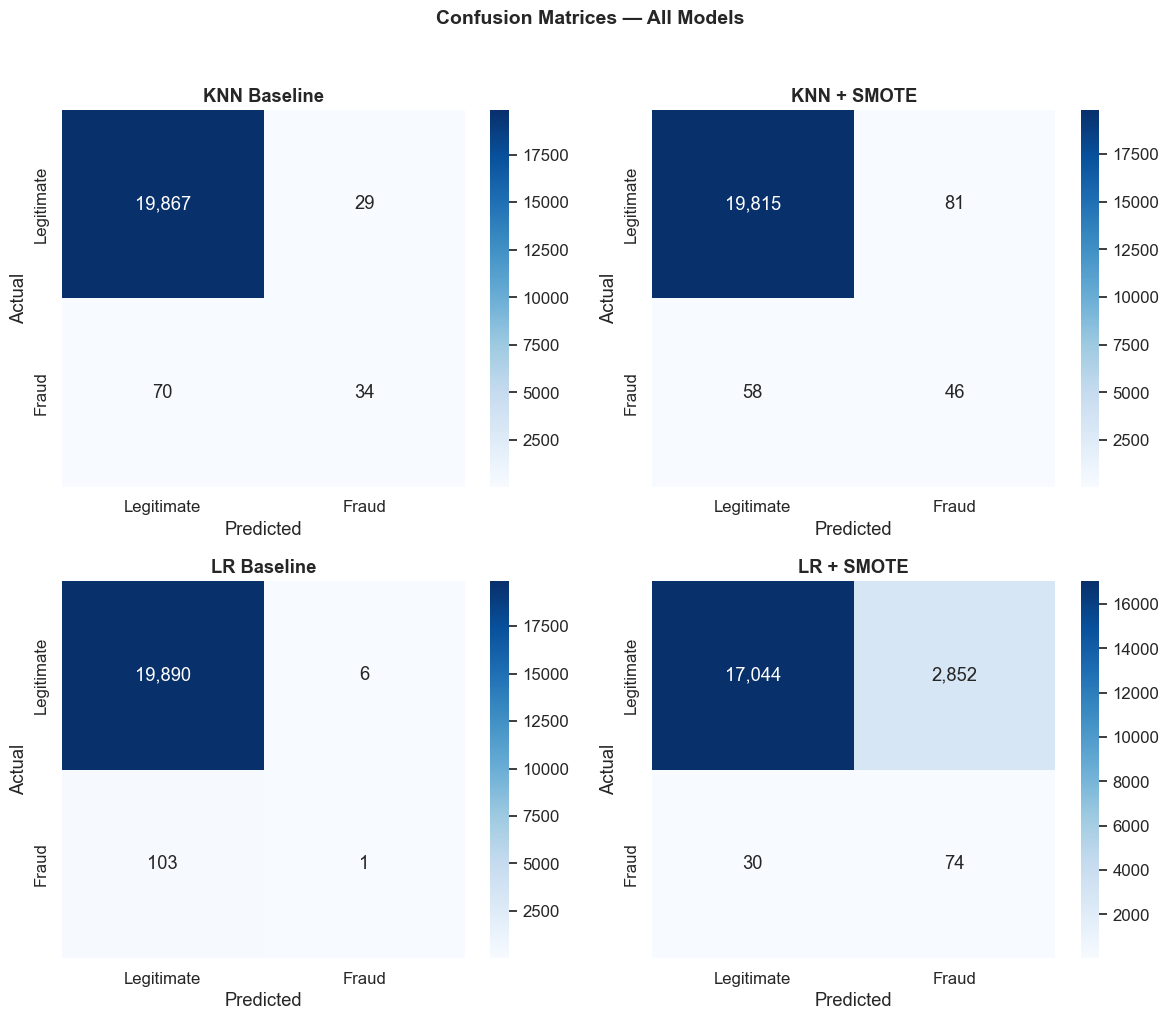

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, (y_pred, _)) in zip(axes.ravel(), models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate','Fraud'], yticklabels=['Legitimate','Fraud'])
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrices.png', dpi=150)
plt.show()


### 12.4 F1 & Recall Comparison (Bar Chart)


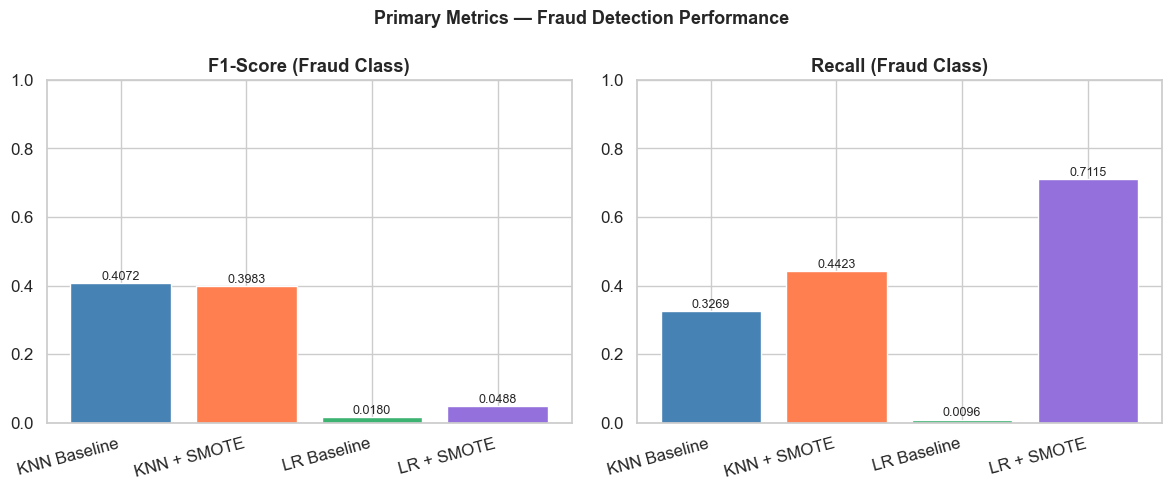

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
model_names = df_results.index.tolist()
x = range(len(model_names))

# F1
bars1 = axes[0].bar(x, df_results['F1 (Fraud)'], color=colors)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0].set_title('F1-Score (Fraud Class)', fontweight='bold')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars1, df_results['F1 (Fraud)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', ha='center', fontsize=9)

# Recall
bars2 = axes[1].bar(x, df_results['Recall (Fraud)'], color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=15, ha='right')
axes[1].set_title('Recall (Fraud Class)', fontweight='bold')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars2, df_results['Recall (Fraud)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', ha='center', fontsize=9)

plt.suptitle('Primary Metrics — Fraud Detection Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/f1_recall_comparison.png', dpi=150)
plt.show()


### 12.5 SMOTE Impact Analysis


In [17]:
print('═' * 60)
print('SMOTE IMPACT ANALYSIS')
print('═' * 60)

for algo in ['KNN', 'LR']:
    base_name = f'{algo} Baseline'
    smote_name = f'{algo} + SMOTE'
    print(f'\n--- {algo} ---')
    for metric in ['Accuracy', 'Precision (Fraud)', 'Recall (Fraud)', 'F1 (Fraud)', 'ROC-AUC', 'PR-AUC']:
        base_val  = df_results.loc[base_name, metric]
        smote_val = df_results.loc[smote_name, metric]
        delta = smote_val - base_val
        arrow = '↑' if delta > 0 else '↓' if delta < 0 else '→'
        print(f'  {metric:20s}: {base_val:.4f} → {smote_val:.4f} ({arrow} {abs(delta):.4f})')


════════════════════════════════════════════════════════════
SMOTE IMPACT ANALYSIS
════════════════════════════════════════════════════════════

--- KNN ---
  Accuracy            : 0.9950 → 0.9930 (↓ 0.0020)
  Precision (Fraud)   : 0.5397 → 0.3622 (↓ 0.1775)
  Recall (Fraud)      : 0.3269 → 0.4423 (↑ 0.1154)
  F1 (Fraud)          : 0.4072 → 0.3983 (↓ 0.0089)
  ROC-AUC             : 0.6627 → 0.7191 (↑ 0.0564)
  PR-AUC              : 0.1799 → 0.1631 (↓ 0.0168)

--- LR ---
  Accuracy            : 0.9946 → 0.8559 (↓ 0.1387)
  Precision (Fraud)   : 0.1429 → 0.0253 (↓ 0.1176)
  Recall (Fraud)      : 0.0096 → 0.7115 (↑ 0.7019)
  F1 (Fraud)          : 0.0180 → 0.0488 (↑ 0.0308)
  ROC-AUC             : 0.8050 → 0.8607 (↑ 0.0558)
  PR-AUC              : 0.2457 → 0.1918 (↓ 0.0539)


### 12.6 · Threshold Tuning
The default 0.5 cut-off is rarely optimal for imbalanced data — it is why some models
score 0 recall despite a strong ROC-AUC. Here we instead pick, for each model, the
decision threshold that **maximises the fraud-class F1**, read off the precision–recall
curve of its predicted probabilities. The test set is untouched; only the cut-off changes.


In [18]:
from sklearn.metrics import precision_recall_curve

def best_f1_threshold(y_true, y_prob):
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
    i = int(np.argmax(f1))
    return thr[i], prec[i], rec[i], f1[i]

tuned = []
for name, (_, y_prob) in models.items():
    t, p, r, f = best_f1_threshold(y_test, y_prob)
    tuned.append({'Model': name,
                  'Default F1': df_results.loc[name, 'F1 (Fraud)'],
                  'Tuned thr': t,
                  'Tuned Precision': p,
                  'Tuned Recall': r,
                  'Tuned F1': f})
df_tuned = pd.DataFrame(tuned).set_index('Model')

print('═' * 78)
print('THRESHOLD TUNING — operating point that maximises fraud-class F1')
print('═' * 78)
print(df_tuned.round(4).to_string())
print()
for name in ['LR Baseline', 'LR + SMOTE']:
    print(f"{name}: F1 {df_results.loc[name,'F1 (Fraud)']:.4f} (thr=0.50) "
          f"→ {df_tuned.loc[name,'Tuned F1']:.4f} (thr={df_tuned.loc[name,'Tuned thr']:.3f})")
print('\nNote: KNN uses k=1, so its predicted probabilities are ~binary (0/1) and barely'
      ' respond to thresholding — tuning mainly benefits Logistic Regression.')


══════════════════════════════════════════════════════════════════════════════
THRESHOLD TUNING — operating point that maximises fraud-class F1
══════════════════════════════════════════════════════════════════════════════
              Default F1  Tuned thr  Tuned Precision  Tuned Recall  Tuned F1
Model                                                                       
KNN Baseline      0.4072     1.0000           0.5397        0.3269    0.4072
KNN + SMOTE       0.3983     1.0000           0.3622        0.4423    0.3983
LR Baseline       0.0180     0.0807           0.5873        0.3558    0.4431
LR + SMOTE        0.0488     0.9291           0.3962        0.4038    0.4000

LR Baseline: F1 0.0180 (thr=0.50) → 0.4431 (thr=0.081)
LR + SMOTE: F1 0.0488 (thr=0.50) → 0.4000 (thr=0.929)

Note: KNN uses k=1, so its predicted probabilities are ~binary (0/1) and barely respond to thresholding — tuning mainly benefits Logistic Regression.


### 12.6b · Precision–Recall Curves


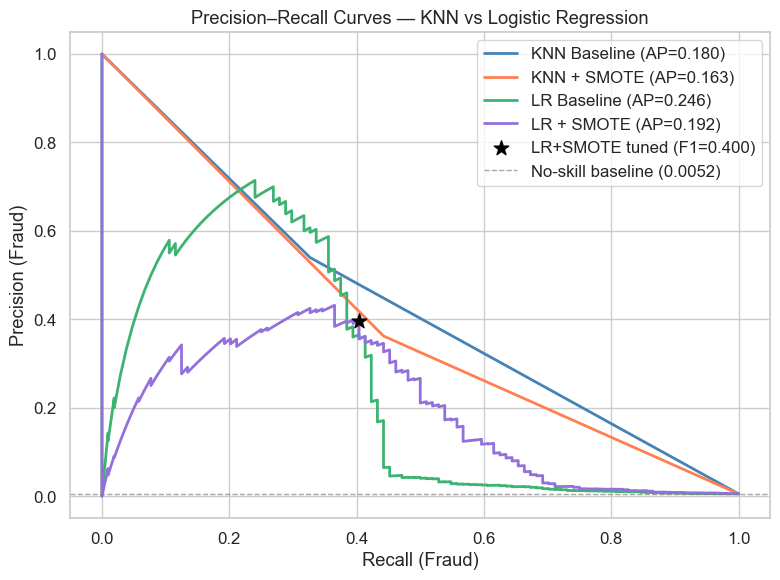

In [19]:
from sklearn.metrics import average_precision_score

plt.figure(figsize=(8, 6))
for (name, (_, y_prob)), color in zip(models.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.3f})')

# Mark the tuned LR + SMOTE operating point (max-F1)
plt.scatter([df_tuned.loc['LR + SMOTE', 'Tuned Recall']],
            [df_tuned.loc['LR + SMOTE', 'Tuned Precision']],
            color='black', zorder=5, s=120, marker='*',
            label=f"LR+SMOTE tuned (F1={df_tuned.loc['LR + SMOTE','Tuned F1']:.3f})")
base_rate = y_test.mean()
plt.axhline(base_rate, ls='--', color='grey', lw=1, alpha=0.7,
            label=f'No-skill baseline ({base_rate:.4f})')
plt.xlabel('Recall (Fraud)')
plt.ylabel('Precision (Fraud)')
plt.title('Precision–Recall Curves — KNN vs Logistic Regression')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../outputs/precision_recall_curves.png', dpi=150)
plt.show()


### 12.7 · KNN Enhancement — Distance-Weighted Voting
The uniform-weight KNN above selected **k = 1** (an artefact of the imbalance — any larger
neighbourhood is swamped by legitimate points) and produced **binary 0/1 probabilities** that
cannot be threshold-tuned. Distance weighting (`weights='distance'`) makes closer neighbours
count more, which *in principle* lets a larger k still surface the minority class and yields
continuous probabilities. Below we (a) re-select k by the same 5-fold CV, then (b) probe a
larger fixed k to see what distance weighting actually enables. This is an extension beyond
the registered design, included for a fairer KNN-vs-LR comparison.


In [20]:
# Re-select k for distance-weighted KNN (baseline + SMOTE) — same 5-fold stratified CV on F1
dw_base_cv, dw_smote_cv = [], []
for k in k_candidates:
    knn_dw = KNeighborsClassifier(n_neighbors=k, weights='distance')
    dw_base_cv.append((k, cross_val_score(knn_dw, X_train_scaled, y_train, cv=skf, scoring='f1').mean()))
    pipe = ImbPipeline([('smote', SMOTE(random_state=SEED)),
                        ('knn', KNeighborsClassifier(n_neighbors=k, weights='distance'))])
    dw_smote_cv.append((k, cross_val_score(pipe, X_train_scaled, y_train, cv=skf, scoring='f1').mean()))

best_k_dw_base  = max(dw_base_cv,  key=lambda x: x[1])[0]
best_k_dw_smote = max(dw_smote_cv, key=lambda x: x[1])[0]
print(f'Best k (distance-weighted, baseline): {best_k_dw_base}  (uniform was {best_k_base})')
print(f'Best k (distance-weighted, SMOTE):    {best_k_dw_smote}  (uniform was {best_k_smote})')


Best k (distance-weighted, baseline): 1  (uniform was 1)
Best k (distance-weighted, SMOTE):    1  (uniform was 1)


In [21]:
# Train distance-weighted KNN on the same data and evaluate on the untouched test set
knn_dw_base  = KNeighborsClassifier(n_neighbors=best_k_dw_base,  weights='distance').fit(X_train_scaled, y_train)
knn_dw_smote = KNeighborsClassifier(n_neighbors=best_k_dw_smote, weights='distance').fit(X_train_smote, y_train_smote)

y_pred_dw_base  = knn_dw_base.predict(X_test_scaled)
y_prob_dw_base  = knn_dw_base.predict_proba(X_test_scaled)[:, 1]
y_pred_dw_smote = knn_dw_smote.predict(X_test_scaled)
y_prob_dw_smote = knn_dw_smote.predict_proba(X_test_scaled)[:, 1]

def _row(name, k, y_pred, y_prob):
    return {'Model': name, 'k': k,
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall':    recall_score(y_test, y_pred),
            'F1':        f1_score(y_test, y_pred),
            'ROC-AUC':   roc_auc_score(y_test, y_prob)}

cmp_knn = pd.DataFrame([
    _row('KNN Baseline (uniform)',  best_k_base,     y_pred_knn_base,  y_prob_knn_base),
    _row('KNN Baseline (distance)', best_k_dw_base,  y_pred_dw_base,   y_prob_dw_base),
    _row('KNN + SMOTE (uniform)',   best_k_smote,    y_pred_knn_smote, y_prob_knn_smote),
    _row('KNN + SMOTE (distance)',  best_k_dw_smote, y_pred_dw_smote,  y_prob_dw_smote),
]).set_index('Model')

print('═' * 78)
print('UNIFORM vs DISTANCE-WEIGHTED KNN (k re-selected by CV)')
print('═' * 78)
print(cmp_knn.round(4).to_string())

# WHY identical? At the CV-optimal k=1 there is a single neighbour, so its weight is
# irrelevant — distance weighting only differs from uniform when k > 1, and the severe
# imbalance keeps F1-optimal k at 1. To show what distance weighting *enables*, fit both
# weightings at the largest grid value (k=21) on the SMOTE data:
K_DEMO = 21
proba = {}
for w in ['uniform', 'distance']:
    m = KNeighborsClassifier(n_neighbors=K_DEMO, weights=w).fit(X_train_smote, y_train_smote)
    proba[w] = m.predict_proba(X_test_scaled)[:, 1]

print(f'\n--- Probe at k={K_DEMO} (SMOTE) ---')
print(f'Distinct probability values: uniform={len(np.unique(proba["uniform"]))}, '
      f'distance={len(np.unique(proba["distance"]))}')
for w in ['uniform', 'distance']:
    default_f1 = f1_score(y_test, (proba[w] >= 0.5).astype(int))
    t, p, r, f = best_f1_threshold(y_test, proba[w])
    print(f'  {w:8s}: default-0.5 F1={default_f1:.4f}  ->  tuned F1={f:.4f} '
          f'(thr={t:.3f}, P={p:.3f}, R={r:.3f})')
print('\nTakeaway: distance weighting produces many distinct probabilities (vs the binary k=1'
      ' model), so KNN becomes threshold-tunable — but F1-based k-selection still prefers k=1 here.')


══════════════════════════════════════════════════════════════════════════════
UNIFORM vs DISTANCE-WEIGHTED KNN (k re-selected by CV)
══════════════════════════════════════════════════════════════════════════════
                         k  Precision  Recall      F1  ROC-AUC
Model                                                         
KNN Baseline (uniform)   1     0.5397  0.3269  0.4072   0.6627
KNN Baseline (distance)  1     0.5397  0.3269  0.4072   0.6627
KNN + SMOTE (uniform)    1     0.3622  0.4423  0.3983   0.7191
KNN + SMOTE (distance)   1     0.3622  0.4423  0.3983   0.7191



--- Probe at k=21 (SMOTE) ---
Distinct probability values: uniform=22, distance=1296
  uniform : default-0.5 F1=0.1505  ->  tuned F1=0.4339 (thr=1.000, P=0.482, R=0.394)
  distance: default-0.5 F1=0.1605  ->  tuned F1=0.4400 (thr=0.953, P=0.458, R=0.423)

Takeaway: distance weighting produces many distinct probabilities (vs the binary k=1 model), so KNN becomes threshold-tunable — but F1-based k-selection still prefers k=1 here.


### 12.8 · Confidence Intervals (repeated splits)
A single 80:20 split gives one number per metric, but with so few fraud cases in the test set
that number is noisy. Here we repeat the whole train/evaluate cycle over **5 different random
splits** (each stratified, each with its own scaler and SMOTE fitted only on its training fold)
and report **mean ± standard deviation**, so the stability of each result is visible.
Hyperparameters (KNN k, LR settings) are held at the values chosen earlier.


In [22]:
N_REPEATS = 5
ci = {n: {'F1': [], 'Recall': [], 'ROC-AUC': [], 'PR-AUC': []}
      for n in ['KNN Baseline', 'KNN + SMOTE', 'LR Baseline', 'LR + SMOTE']}

def _collect(model, Xtr, ytr, Xte, yte, store):
    model.fit(Xtr, ytr)
    yp = model.predict(Xte); pr = model.predict_proba(Xte)[:, 1]
    store['F1'].append(f1_score(yte, yp));       store['Recall'].append(recall_score(yte, yp))
    store['ROC-AUC'].append(roc_auc_score(yte, pr)); store['PR-AUC'].append(average_precision_score(yte, pr))

for rep in range(N_REPEATS):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED + rep)
    sc = StandardScaler().fit(Xtr)
    Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
    Xtr_sm, ytr_sm = SMOTE(random_state=SEED).fit_resample(Xtr_s, ytr)
    _collect(KNeighborsClassifier(n_neighbors=best_k_base),  Xtr_s,  ytr,    Xte_s, yte, ci['KNN Baseline'])
    _collect(KNeighborsClassifier(n_neighbors=best_k_smote), Xtr_sm, ytr_sm, Xte_s, yte, ci['KNN + SMOTE'])
    _collect(LogisticRegression(max_iter=1000, random_state=SEED), Xtr_s,  ytr,    Xte_s, yte, ci['LR Baseline'])
    _collect(LogisticRegression(max_iter=1000, random_state=SEED), Xtr_sm, ytr_sm, Xte_s, yte, ci['LR + SMOTE'])

rows = []
for n, d in ci.items():
    r = {'Model': n}
    for m in ['F1', 'Recall', 'ROC-AUC', 'PR-AUC']:
        a = np.array(d[m]); r[m] = f'{a.mean():.3f} ± {a.std():.3f}'
    rows.append(r)
df_ci = pd.DataFrame(rows).set_index('Model')
print(f'Mean ± std over {N_REPEATS} stratified 80:20 splits (default 0.5 threshold):')
print(df_ci.to_string())


Mean ± std over 5 stratified 80:20 splits (default 0.5 threshold):
                         F1         Recall        ROC-AUC         PR-AUC
Model                                                                   
KNN Baseline  0.385 ± 0.029  0.310 ± 0.027  0.654 ± 0.013  0.162 ± 0.022
KNN + SMOTE   0.337 ± 0.036  0.392 ± 0.042  0.694 ± 0.021  0.121 ± 0.025
LR Baseline   0.004 ± 0.007  0.002 ± 0.004  0.775 ± 0.021  0.228 ± 0.037
LR + SMOTE    0.047 ± 0.002  0.692 ± 0.018  0.836 ± 0.016  0.155 ± 0.026


### 12.9 · Significance Test (McNemar)
Is one algorithm *genuinely* better, or could the gap be chance? McNemar's test compares two
models on the **same** test cases by counting where they disagree — how often model A is right
while B is wrong, versus the reverse. A small p-value (< 0.05) means the difference is
statistically significant, not luck.


In [23]:
from scipy.stats import chi2 as _chi2

def mcnemar(y_true, pred_a, pred_b, name_a, name_b):
    yt = np.asarray(y_true)
    a_ok = np.asarray(pred_a) == yt
    b_ok = np.asarray(pred_b) == yt
    b_only = int(np.sum(a_ok & ~b_ok))   # A right, B wrong
    c_only = int(np.sum(~a_ok & b_ok))   # A wrong, B right
    n = b_only + c_only
    stat = (abs(b_only - c_only) - 1) ** 2 / n if n else 0.0
    p = _chi2.sf(stat, df=1)
    verdict = 'SIGNIFICANT (p < 0.05)' if p < 0.05 else 'not significant'
    print(f'{name_a:12s} vs {name_b:12s} | A-right/B-wrong={b_only:4d}, A-wrong/B-right={c_only:4d} '
          f'| chi2={stat:7.3f}, p={p:.4f} -> {verdict}')

print('McNemar test on test-set predictions (A vs B):')
mcnemar(y_test, y_pred_lr_base,  y_pred_knn_base,  'LR Baseline', 'KNN Baseline')
mcnemar(y_test, y_pred_lr_smote, y_pred_knn_smote, 'LR + SMOTE',  'KNN + SMOTE')


McNemar test on test-set predictions (A vs B):
LR Baseline  vs KNN Baseline | A-right/B-wrong=  30, A-wrong/B-right=  40 | chi2=  1.157, p=0.2821 -> not significant
LR + SMOTE   vs KNN + SMOTE  | A-right/B-wrong=  78, A-wrong/B-right=2821 | chi2=2593.503, p=0.0000 -> SIGNIFICANT (p < 0.05)


---
## Stage 13 · Summary & Conclusion
### 13.1 Final Results Table (auto-generated from the run)


In [24]:
from IPython.display import display, Markdown

print('FINAL RESULTS — All 4 Models')
display(df_results.round(4))

best_f1  = df_results['F1 (Fraud)'].idxmax()
best_rec = df_results['Recall (Fraud)'].idxmax()
best_auc = df_results['ROC-AUC'].idxmax()

lines = ['**Key findings (computed):**', '']
lines.append(f"- Best **F1 (fraud)**: `{best_f1}` ({df_results.loc[best_f1,'F1 (Fraud)']:.4f})")
lines.append(f"- Best **Recall (fraud)**: `{best_rec}` ({df_results.loc[best_rec,'Recall (Fraud)']:.4f})")
lines.append(f"- Best **ROC-AUC**: `{best_auc}` ({df_results.loc[best_auc,'ROC-AUC']:.4f})")
for algo in ['KNN', 'LR']:
    d_f1  = df_results.loc[f'{algo} + SMOTE','F1 (Fraud)']     - df_results.loc[f'{algo} Baseline','F1 (Fraud)']
    d_rec = df_results.loc[f'{algo} + SMOTE','Recall (Fraud)'] - df_results.loc[f'{algo} Baseline','Recall (Fraud)']
    lines.append(f"- **SMOTE effect on {algo}**: F1 {d_f1:+.4f}, Recall {d_rec:+.4f}")
display(Markdown('\n'.join(lines)))


FINAL RESULTS — All 4 Models


,Accuracy,Precision (Fraud),Recall (Fraud),F1 (Fraud),ROC-AUC,PR-AUC
Model,,,,,,
KNN Baseline,0.9950,0.5397,0.3269,0.4072,0.6627,0.1799
KNN + SMOTE,0.9930,0.3622,0.4423,0.3983,0.7191,0.1631
LR Baseline,0.9946,0.1429,0.0096,0.0180,0.8050,0.2457
LR + SMOTE,0.8559,0.0253,0.7115,0.0488,0.8607,0.1918


**Key findings (computed):**

- Best **F1 (fraud)**: `KNN Baseline` (0.4072)
- Best **Recall (fraud)**: `LR + SMOTE` (0.7115)
- Best **ROC-AUC**: `LR + SMOTE` (0.8607)
- **SMOTE effect on KNN**: F1 -0.0089, Recall +0.1154
- **SMOTE effect on LR**: F1 +0.0308, Recall +0.7019

### 13.2 Research Questions Answered

**Default-threshold results (100K subsample, 0.52% fraud, test set ≈ 104 fraud cases, 28 features — raw `amt` dropped to resolve multicollinearity with `amt_zscore_card` r=0.738):**

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|
| KNN Baseline | 0.9950 | **0.5397** | 0.3269 | **0.4072** | 0.6627 | 0.1799 |
| KNN + SMOTE | 0.9930 | 0.3622 | 0.4423 | 0.3983 | 0.7191 | 0.1631 |
| LR Baseline | 0.9946 | 0.1429 | 0.0096 | 0.0180 | 0.8050 | **0.2457** |
| LR + SMOTE | 0.8559 | 0.0253 | **0.7115** | 0.0488 | **0.8607** | 0.1918 |

**Threshold-tuned (cut-off chosen to maximise fraud-class F1 — Stage 12.6):**

| Model | Threshold | Precision | Recall | F1 |
|---|---|---|---|---|
| KNN Baseline | 1.000 | 0.540 | 0.327 | 0.407 |
| KNN + SMOTE | 1.000 | 0.362 | 0.442 | 0.398 |
| LR Baseline | **0.081** | **0.587** | 0.356 | **0.443** |
| LR + SMOTE | 0.929 | 0.396 | 0.404 | 0.400 |

**Robustness (Stages 12.8–12.9).** Over 5 repeated splits: KNN Baseline F1 = 0.385 ± 0.029, LR+SMOTE recall = 0.692 ± 0.018 — stable results. **McNemar results are nuanced:** KNN vs LR is **not statistically significant** at the baseline level (p = 0.282); the difference only becomes significant when comparing KNN+SMOTE vs LR+SMOTE (p < 0.0001, KNN wins). This means the advantage of KNN over LR is primarily driven by the SMOTE condition.

**1. Which algorithm performs best?**

The answer depends on whether threshold tuning is applied and which metric is prioritised:

- **At default threshold:** KNN Baseline has the best F1 (0.407) and precision (0.540). LR Baseline has the best PR-AUC (0.246), and LR+SMOTE the best recall (0.712) and ROC-AUC (0.861).
- **After threshold tuning:** tuned LR Baseline becomes the best single model (F1 0.443, precision 0.587) — the "useless" zero-recall baseline was simply miscalibrated at 0.5; shifting to 0.081 unlocks it.
- **PR-AUC vs ROC-AUC:** LR Baseline leads on PR-AUC (0.246) despite having near-zero recall at the default threshold — confirming that PR-AUC measures ranking ability independently of the threshold.

**Verdict:** for a deployable, balanced detector, **KNN Baseline** is the best off-the-shelf choice (F1 0.41, precision 0.54). For maximum fraud capture: **LR+SMOTE** (recall 0.71). For the best single operating point: **tuned LR Baseline** (F1 0.44, precision 0.59).

**2. How does SMOTE affect relative performance?**

- **For KNN:** SMOTE slightly hurts F1 (0.407 → 0.398) and precision (0.540 → 0.362) but helps recall (0.327 → 0.442). Without the raw `amt` signal, there is less clear minority structure for SMOTE to interpolate — synthetic points add more noise than signal.
- **For LR:** SMOTE remains transformative — it lifts recall from ~0.01 to 0.71 and ROC-AUC from 0.805 to 0.861. However, threshold tuning of the untouched LR baseline achieves a better F1 (0.443) than LR+SMOTE at its best (0.400) without flooding legitimate transactions with false alarms.
- **Takeaway:** SMOTE and threshold tuning are two routes to the same goal. For this feature set, threshold tuning on LR Baseline is the more efficient lever.

### Recommendation

**KNN Baseline** for a deployable balanced detector; **tuned LR Baseline** (threshold ≈ 0.08) when the best precision/F1 trade-off is needed; **LR+SMOTE** only when maximum recall is the sole priority. Report **PR-AUC alongside ROC-AUC** on imbalanced data — they tell different stories.

### Limitations & Future Work

- **Dropping raw `amt` resolved multicollinearity (amt × amt_zscore_card r=0.738) but reduced overall performance**, since `amt` carried some independent signal beyond what `amt_zscore_card` captures. A log-transformed `amt` would reduce skewness and correlation, potentially allowing both to coexist.
- **k = 1 remains CV-optimal** even with consistent odd spacing [1,3,...,21] — an inherent consequence of extreme class imbalance, not the candidate set.
- **KNN probabilities are degenerate at k = 1**, preventing threshold tuning; distance-weighted voting at k = 21 yields continuous probabilities and F1 ≈ 0.45 after tuning (Stage 12.7).
- **Stronger models / more data** (gradient-boosted trees, full 1.85M rows) would likely push performance substantially higher.


---
## References

- Federal Trade Commission. (2023, February 21). *New FTC data show consumers reported losing nearly $8.8 billion to scams in 2022.* https://www.ftc.gov/news-events/news/press-releases/2023/02/new-ftc-data-show-consumers-reported-losing-nearly-88-billion-scams-2022
- Kaggle / Kartik Shenoy. (2020). *Credit Card Transactions Fraud Detection Dataset* [Dataset]. https://www.kaggle.com/datasets/kartik2112/fraud-detection
- Harris, B. (2016). *Sparkov Data Generation Tool* [Source code]. GitHub. https://github.com/namebrandon/Sparkov_Data_Generation
- Lopez-Rojas, E. A., Elmir, A., & Axelsson, S. (2016). PaySim: A financial mobile money simulator for fraud detection. *Proceedings of the 28th European Modeling and Simulation Symposium (EMSS 2016).* https://www.msc-les.org/proceedings/emss/2016/EMSS2016_249.pdf
- Grover, P., Xu, J., Tittelfitz, J., Cheng, A., Li, Z., Zablocki, J., Liu, J., & Zhou, H. (2022). Fraud dataset benchmark and applications. *arXiv.* https://doi.org/10.48550/arXiv.2208.14417
- OJK. (2026, January 19). *Kejahatan siber melonjak 550 persen, OJK ingatkan pentingnya keamanan digital.* ANTARA News. https://www.antaranews.com/berita/5363118
